Section A – Imports, environment, dataset discovery, metadata loading, binary mapping, caching setup.

In [4]:
import os
import ast
import random
import warnings

!pip install xgboost wfdb -q  # Installed both quietly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb  # This will now import smoothly!

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("Num GPUs   :", len(tf.config.list_physical_devices("GPU")))

TensorFlow : 2.19.0
Num GPUs   : 2


In [5]:
BASE_PATH = "/kaggle/input/datasets"

OWNER = os.listdir(BASE_PATH)[0]

DATASET = os.listdir(
    os.path.join(BASE_PATH, OWNER)
)[0]

VERSION = os.listdir(
    os.path.join(BASE_PATH, OWNER, DATASET)
)[0]

PTBXL_PATH = os.path.join(
    BASE_PATH,
    OWNER,
    DATASET,
    VERSION
)

print("Dataset Path:")
print(PTBXL_PATH)

Dataset Path:
/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1


In [6]:
CACHE_DIR = "/kaggle/working/cache"

RESULT_DIR = "/kaggle/working/results"

MODEL_DIR = os.path.join(RESULT_DIR, "models")
METRIC_DIR = os.path.join(RESULT_DIR, "metrics")
PLOT_DIR = os.path.join(RESULT_DIR, "plots")
PRED_DIR = os.path.join(RESULT_DIR, "predictions")

for folder in [
    CACHE_DIR,
    RESULT_DIR,
    MODEL_DIR,
    METRIC_DIR,
    PLOT_DIR,
    PRED_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Working folders created.")

Working folders created.


In [7]:
metadata = pd.read_csv(
    os.path.join(
        PTBXL_PATH,
        "ptbxl_database.csv"
    ),
    index_col="ecg_id"
)

metadata["scp_codes"] = metadata["scp_codes"].apply(
    ast.literal_eval
)

scp = pd.read_csv(
    os.path.join(
        PTBXL_PATH,
        "scp_statements.csv"
    ),
    index_col=0
)

scp = scp[
    scp["diagnostic"] == 1
]

print(metadata.shape)
metadata.head()

(21837, 27)


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [10]:
def aggregate_diagnostic(scp_codes):

    classes = []

    for code in scp_codes.keys():

        if code in scp.index:

            classes.append(
                scp.loc[
                    code,
                    "diagnostic_class"
                ]
            )

    return list(set(classes))


metadata["diagnostic_superclass"] = metadata[
    "scp_codes"
].apply(
    aggregate_diagnostic
)

def map_binary(classes):

    if len(classes) == 0:
        return np.nan

    if classes == ["NORM"]:
        return 0

    return 1


metadata["target_binary"] = metadata[
    "diagnostic_superclass"
].apply(
    map_binary
)

metadata = metadata.dropna(
    subset=["target_binary"]
)

metadata["target_binary"] = metadata[
    "target_binary"
].astype(int)

In [11]:
print("Dataset Shape :", metadata.shape)

print()

print(
    metadata["target_binary"].value_counts()
)

print()

print(
    "Unique Patients :",
    metadata["patient_id"].nunique()
)

print()

print(
    metadata[
        [
            "patient_id",
            "filename_lr",
            "target_binary"
        ]
    ].head()
)

Dataset Shape : (21430, 29)

target_binary
1    12347
0     9083
Name: count, dtype: int64

Unique Patients : 18637

        patient_id                filename_lr  target_binary
ecg_id                                                      
1          15709.0  records100/00000/00001_lr              0
2          13243.0  records100/00000/00002_lr              0
3          20372.0  records100/00000/00003_lr              0
4          17014.0  records100/00000/00004_lr              0
5          17448.0  records100/00000/00005_lr              0


In [12]:
X_CACHE = os.path.join(
    CACHE_DIR,
    "X_full.npy"
)

Y_CACHE = os.path.join(
    CACHE_DIR,
    "y_full.npy"
)

PATIENT_CACHE = os.path.join(
    CACHE_DIR,
    "patient_ids.npy"
)

if (
    os.path.exists(X_CACHE)
    and
    os.path.exists(Y_CACHE)
    and
    os.path.exists(PATIENT_CACHE)
):

    print("Cached ECG arrays found.")

else:

    print("No cache found.")

    print("Signals will be processed.")

No cache found.
Signals will be processed.


Section B — Load & Cache ALL ECG Signals

This is the heaviest section in the entire notebook.

It has three jobs:

Metadata
      ↓
Read 21,430 WFDB files
      ↓
Normalize each ECG
      ↓
Save cache (.npy)* 

In [13]:
if (
    os.path.exists(X_CACHE)
    and
    os.path.exists(Y_CACHE)
    and
    os.path.exists(PATIENT_CACHE)
):

    print("Loading cached arrays...\n")

    X = np.load(X_CACHE)
    y = np.load(Y_CACHE)
    patient_ids = np.load(PATIENT_CACHE)

else:

    print("Reading ECG signals from PTB-XL...\n")

    X = []
    y = []
    patient_ids = []

    total = len(metadata)

    for i, (ecg_id, row) in enumerate(metadata.iterrows(), start=1):

        signal_path = os.path.join(
            PTBXL_PATH,
            row["filename_lr"]
        )

        signal, _ = wfdb.rdsamp(signal_path)

        X.append(signal.astype(np.float32))
        y.append(row["target_binary"])
        patient_ids.append(row["patient_id"])

        if i % 1000 == 0 or i == total:

            print(f"{i}/{total} ECGs loaded")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    patient_ids = np.array(patient_ids)

    print("\nFinished reading ECGs.")

Reading ECG signals from PTB-XL...

1000/21430 ECGs loaded
2000/21430 ECGs loaded
3000/21430 ECGs loaded
4000/21430 ECGs loaded
5000/21430 ECGs loaded
6000/21430 ECGs loaded
7000/21430 ECGs loaded
8000/21430 ECGs loaded
9000/21430 ECGs loaded
10000/21430 ECGs loaded
11000/21430 ECGs loaded
12000/21430 ECGs loaded
13000/21430 ECGs loaded
14000/21430 ECGs loaded
15000/21430 ECGs loaded
16000/21430 ECGs loaded
17000/21430 ECGs loaded
18000/21430 ECGs loaded
19000/21430 ECGs loaded
20000/21430 ECGs loaded
21000/21430 ECGs loaded
21430/21430 ECGs loaded

Finished reading ECGs.


In [14]:
print("ECG Shape      :", X.shape)
print("Labels Shape   :", y.shape)
print("Patients Shape :", patient_ids.shape)

print()

print("Unique Patients :", len(np.unique(patient_ids)))

print()

print(pd.Series(y).value_counts())

ECG Shape      : (21430, 1000, 12)
Labels Shape   : (21430,)
Patients Shape : (21430,)

Unique Patients : 18637

1    12347
0     9083
Name: count, dtype: int64


In [15]:
print("Normalizing ECGs...")

mean = X.mean(
    axis=1,
    keepdims=True
)

std = X.std(
    axis=1,
    keepdims=True
)

X = (X - mean) / (std + 1e-8)

print("Normalization complete.")

Normalizing ECGs...
Normalization complete.


In [16]:
print("Mean :", np.mean(X))
print("Std  :", np.std(X))

print()

print("Minimum :", np.min(X))
print("Maximum :", np.max(X))

Mean : 7.731155e-10
Std  : 0.999998

Minimum : -27.878325
Maximum : 30.433638


In [17]:
np.save(X_CACHE, X)
np.save(Y_CACHE, y)
np.save(PATIENT_CACHE, patient_ids)

print("Cached arrays saved.")

print()

print(CACHE_DIR)

Cached arrays saved.

/kaggle/working/cache


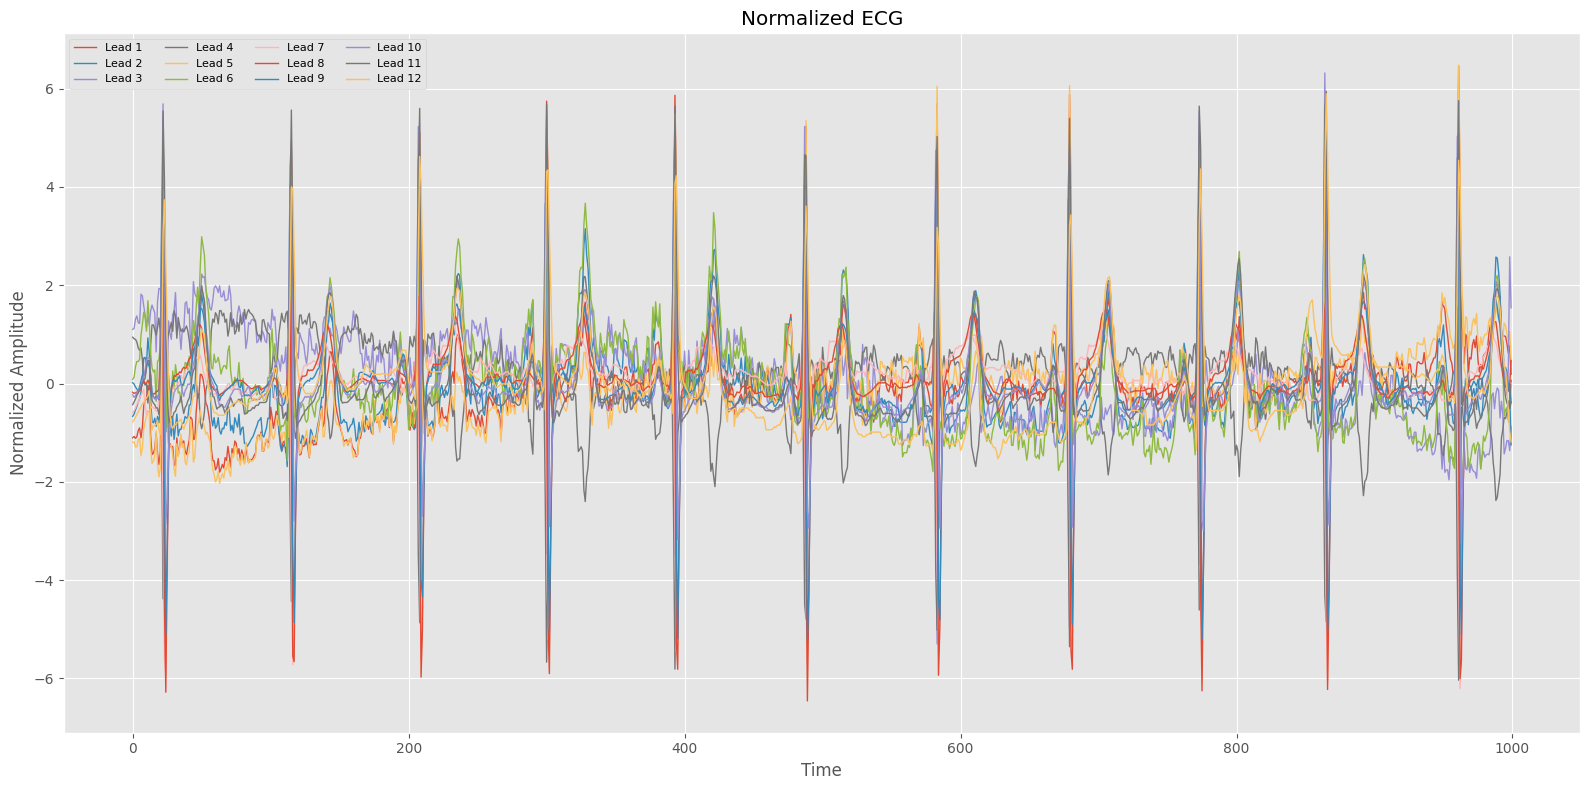

In [18]:
sample = 0

plt.figure(figsize=(16,8))

for lead in range(12):

    plt.plot(
        X[sample,:,lead],
        linewidth=1,
        label=f"Lead {lead+1}"
    )

plt.title("Normalized ECG")

plt.xlabel("Time")

plt.ylabel("Normalized Amplitude")

plt.legend(
    ncol=4,
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "08b_normalized_ecg.png"
    ),
    dpi=300
)

plt.show()

**Section C — Patient-Level Split + TensorFlow Pipeline**

In [19]:
from sklearn.model_selection import GroupShuffleSplit

# -------------------------------
# Step 1 : Train (70%) / Temp (30%)
# -------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss.split(
        X,
        y,
        groups=patient_ids
    )
)

X_train = X[train_idx]
y_train = y[train_idx]
patients_train = patient_ids[train_idx]

X_temp = X[temp_idx]
y_temp = y[temp_idx]
patients_temp = patient_ids[temp_idx]

# -------------------------------
# Step 2 : Validation (15%) / Test (15%)
# -------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    gss.split(
        X_temp,
        y_temp,
        groups=patients_temp
    )
)

X_val = X_temp[val_idx]
y_val = y_temp[val_idx]
patients_val = patients_temp[val_idx]

X_test = X_temp[test_idx]
y_test = y_temp[test_idx]
patients_test = patients_temp[test_idx]

In [20]:
print("="*50)

print("Train")
print(X_train.shape)

print()

print("Validation")
print(X_val.shape)

print()

print("Test")
print(X_test.shape)

print("="*50)

print()

print("Train Labels")
print(pd.Series(y_train).value_counts())

print()

print("Validation Labels")
print(pd.Series(y_val).value_counts())

print()

print("Test Labels")
print(pd.Series(y_test).value_counts())

Train
(14969, 1000, 12)

Validation
(3254, 1000, 12)

Test
(3207, 1000, 12)

Train Labels
1    8613
0    6356
Name: count, dtype: int64

Validation Labels
1    1892
0    1362
Name: count, dtype: int64

Test Labels
1    1842
0    1365
Name: count, dtype: int64


In [21]:
train_patients = set(patients_train)
val_patients = set(patients_val)
test_patients = set(patients_test)

print(
    "Train ∩ Validation :",
    len(train_patients & val_patients)
)

print(
    "Train ∩ Test :",
    len(train_patients & test_patients)
)

print(
    "Validation ∩ Test :",
    len(val_patients & test_patients)
)

Train ∩ Validation : 0
Train ∩ Test : 0
Validation ∩ Test : 0


In [24]:
BATCH_SIZE = 64

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [25]:
for batch_x, batch_y in train_dataset.take(1):

    print("Batch ECG Shape :", batch_x.shape)
    print("Batch Labels    :", batch_y.shape)

Batch ECG Shape : (64, 1000, 12)
Batch Labels    : (64,)


In [26]:
split_summary = pd.DataFrame({

    "Split":[
        "Train",
        "Validation",
        "Test"
    ],

    "ECGs":[
        len(X_train),
        len(X_val),
        len(X_test)
    ],

    "Unique Patients":[
        len(train_patients),
        len(val_patients),
        len(test_patients)
    ]

})

split_summary.to_csv(
    os.path.join(
        METRIC_DIR,
        "08b_dataset_split.csv"
    ),
    index=False
)

split_summary

,Split,ECGs,Unique Patients
0,Train,14969,13045
1,Validation,3254,2796
2,Test,3207,2796


Section D — Final CNN Architecture

In [28]:
checkpoint_path = os.path.join(
    MODEL_DIR,
    "08b_best_cnn.keras"
)

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

]

In [29]:
cnn_model = Sequential([

    Conv1D(
        32,
        kernel_size=7,
        activation="relu",
        padding="same",
        input_shape=(1000,12)
    ),

    BatchNormalization(),

    MaxPooling1D(2),

    Conv1D(
        64,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    MaxPooling1D(2),

    Conv1D(
        128,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    GlobalAveragePooling1D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.4),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )

])

In [30]:
cnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]

)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1000, 32)       │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,457 (247.88 KB)

 Trainable params: 63,009 (246.13 KB)

 Non-trainable params: 448 (1.75 KB)

In [31]:
history = cnn_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=50,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/50


I0000 00:00:1782560477.374706     184 service.cc:152] XLA service 0x7a40080289d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782560477.374748     184 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782560477.374752     184 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782560478.084315     184 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-27 11:41:20.542814: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 11:41:20.545589: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.2 = (f32[64,64,1,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,1,250]{3,2,1,0} %bitcast.10012, f32[128,64,1,3]{3,2,1,0} %bitcast.100

  7/234 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6519 - auc: 0.6156 - loss: 0.6538 

I0000 00:00:1782560484.119074     184 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7887 - auc: 0.8634 - loss: 0.4470
Epoch 1: val_loss improved from None to 0.38524, saving model to /kaggle/working/results/models/08b_best_cnn.keras

Epoch 1: finished saving model to /kaggle/working/results/models/08b_best_cnn.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.8160 - auc: 0.8950 - loss: 0.4001 - val_accuracy: 0.8273 - val_auc: 0.9229 - val_loss: 0.3852 - learning_rate: 0.0010
Epoch 2/50
233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8522 - auc: 0.9238 - loss: 0.3425
Epoch 2: val_loss improved from 0.38524 to 0.34861, saving model to /kaggle/working/results/models/08b_best_cnn.keras

Epoch 2: finished saving model to /kaggle/working/results/models/08b_best_cnn.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8471 - auc: 0.9227 - loss: 0.3446 - val_accuracy: 0.8445 - val_auc: 0.9207 - val_loss: 0.3486 - learning_rate: 0.0010
Epoch 3/50
232/234 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - ac

In [32]:
history_df = pd.DataFrame(history.history)

history_df.to_csv(

    os.path.join(
        METRIC_DIR,
        "08b_training_history.csv"
    ),

    index=False

)

history_df.head()

,accuracy,auc,loss,val_accuracy,val_auc,val_loss,learning_rate
0,0.815953,0.894989,0.400136,0.827289,0.922900,0.385236,0.001
1,0.847084,0.922654,0.344585,0.844499,0.920696,0.348607,0.001
2,0.853297,0.928422,0.331990,0.847572,0.935492,0.330183,0.001
3,0.860846,0.934217,0.318013,0.862323,0.938634,0.311078,0.001
4,0.867593,0.938274,0.309230,0.820529,0.936733,0.379902,0.001


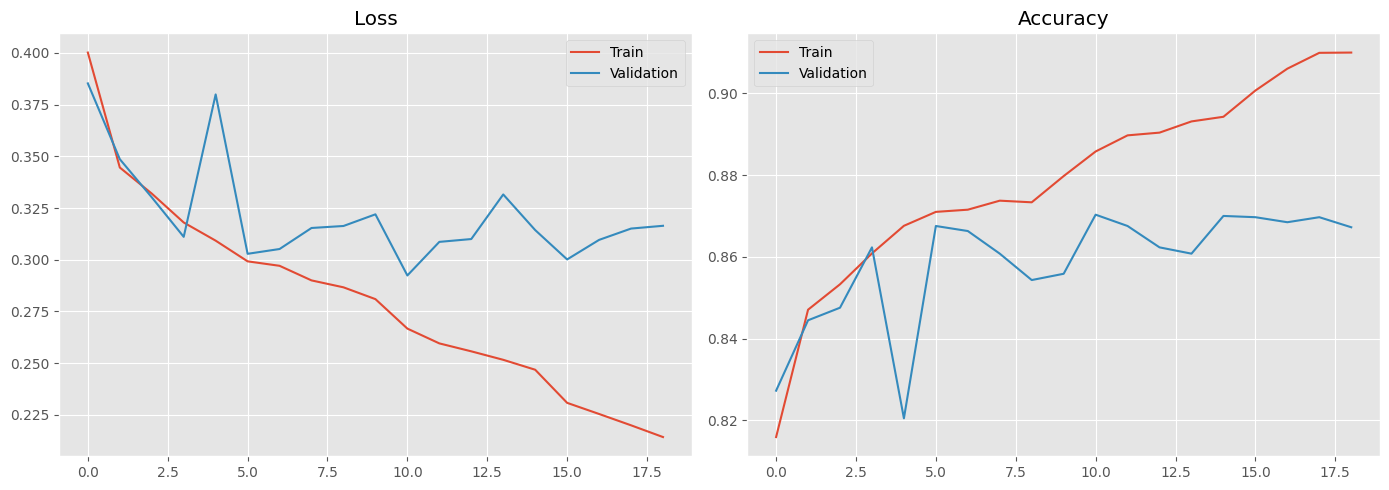

In [33]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")

plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["accuracy"],label="Train")
plt.plot(history.history["val_accuracy"],label="Validation")

plt.title("Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(

    os.path.join(
        PLOT_DIR,
        "08b_learning_curve.png"
    ),

    dpi=300

)

plt.show()

Section E — Final Evaluation & Artifact Export

In [34]:
# Predict probabilities
y_prob = cnn_model.predict(test_dataset).ravel()

# Convert probabilities to labels
y_pred = (y_prob >= 0.5).astype(int)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [35]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("="*60)
print("FINAL ECG MODEL")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print()

print(classification_report(y_test, y_pred))

FINAL ECG MODEL
Accuracy : 0.8740
Precision: 0.9109
Recall   : 0.8654
F1 Score : 0.8875
AUC      : 0.9431

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1365
           1       0.91      0.87      0.89      1842

    accuracy                           0.87      3207
   macro avg       0.87      0.88      0.87      3207
weighted avg       0.88      0.87      0.87      3207



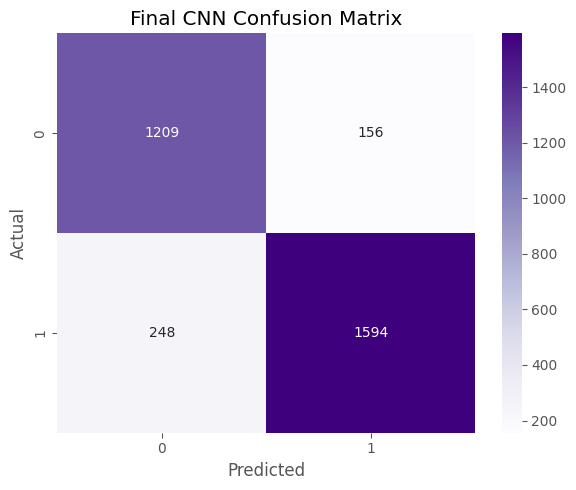

In [36]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Final CNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "08b_confusion_matrix.png"
    ),
    dpi=300
)

plt.show()

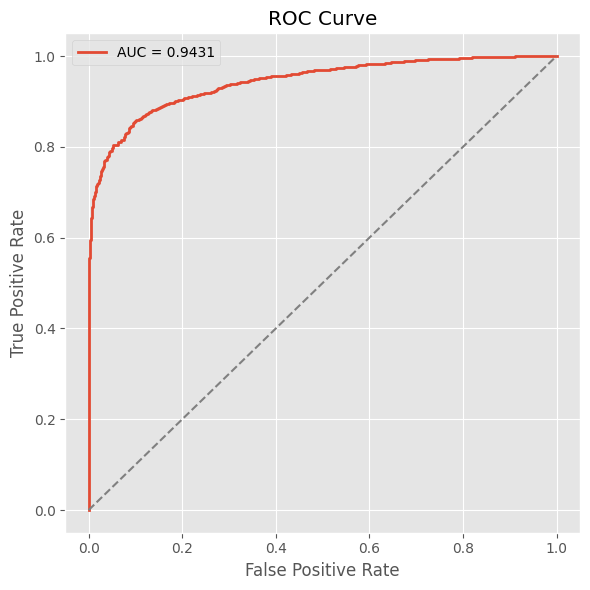

In [37]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "08b_roc_curve.png"
    ),
    dpi=300
)

plt.show()

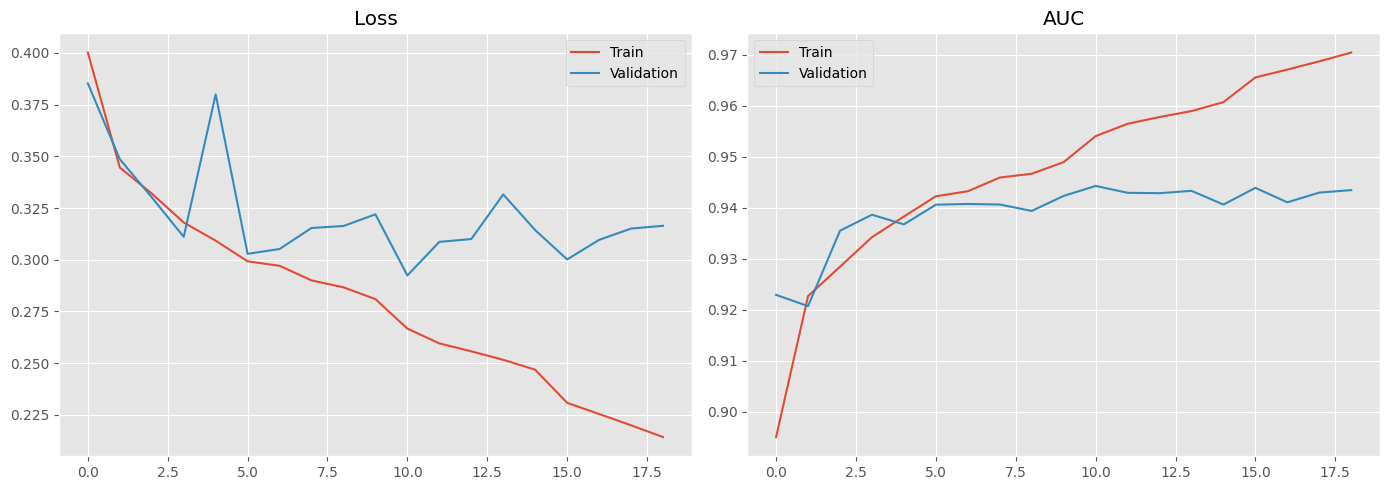

In [38]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].plot(history.history["loss"], label="Train")
ax[0].plot(history.history["val_loss"], label="Validation")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(history.history["auc"], label="Train")
ax[1].plot(history.history["val_auc"], label="Validation")
ax[1].set_title("AUC")
ax[1].legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "08b_training_curves.png"
    ),
    dpi=300
)

plt.show()

In [39]:
metrics_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

metrics_df.to_csv(

    os.path.join(
        METRIC_DIR,
        "08b_final_metrics.csv"
    ),

    index=False

)

metrics_df

,Metric,Value
0,Accuracy,0.874026
1,Precision,0.910857
2,Recall,0.865364
3,F1 Score,0.887528
4,AUC,0.943118


In [40]:
predictions = pd.DataFrame({

    "True Label":y_test,

    "Predicted Label":y_pred,

    "Probability":y_prob

})

predictions.to_csv(

    os.path.join(
        PRED_DIR,
        "08b_predictions.csv"
    ),

    index=False

)

predictions.head()

,True Label,Predicted Label,Probability
0,0,0,0.021853
1,1,0,0.277918
2,0,0,0.167746
3,0,0,0.066557
4,1,1,0.541403


In [41]:
import json

config = {

    "project":"CardioSense AI",

    "model":"CNN Baseline",

    "dataset":"PTB-XL",

    "dataset_version":"1.0.1",

    "sampling_frequency":100,

    "input_shape":[1000,12],

    "signals":int(len(X)),

    "unique_patients":int(len(np.unique(patient_ids))),

    "train_samples":int(len(X_train)),

    "validation_samples":int(len(X_val)),

    "test_samples":int(len(X_test)),

    "batch_size":BATCH_SIZE,

    "epochs_requested":50,

    "epochs_completed":len(history.history["loss"]),

    "best_epoch":int(np.argmin(history.history["val_loss"])+1),

    "optimizer":"Adam",

    "learning_rate":0.001,

    "loss":"Binary Crossentropy",

    "random_seed":SEED

}

with open(

    os.path.join(
        MODEL_DIR,
        "08b_training_config.json"
    ),

    "w"

) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print(config)

{'project': 'CardioSense AI', 'model': 'CNN Baseline', 'dataset': 'PTB-XL', 'dataset_version': '1.0.1', 'sampling_frequency': 100, 'input_shape': [1000, 12], 'signals': 21430, 'unique_patients': 18637, 'train_samples': 14969, 'validation_samples': 3254, 'test_samples': 3207, 'batch_size': 64, 'epochs_requested': 50, 'epochs_completed': 19, 'best_epoch': 11, 'optimizer': 'Adam', 'learning_rate': 0.001, 'loss': 'Binary Crossentropy', 'random_seed': 42}


In [42]:
cnn_model.save(

    os.path.join(
        MODEL_DIR,
        "08b_final_cnn.keras"
    )

)

print("Final CNN model saved.")

Final CNN model saved.


In [43]:
summary = pd.DataFrame({

    "Component":[
        "Dataset",
        "Architecture",
        "Signals",
        "Patients",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ],

    "Value":[
        "PTB-XL",
        "CNN Baseline",
        len(X),
        len(np.unique(patient_ids)),
        round(accuracy,4),
        round(precision,4),
        round(recall,4),
        round(f1,4),
        round(auc,4)
    ]

})

summary.to_csv(

    os.path.join(
        METRIC_DIR,
        "08b_project_summary.csv"
    ),

    index=False

)

summary

,Component,Value
0,Dataset,PTB-XL
1,Architecture,CNN Baseline
2,Signals,21430
3,Patients,18637
4,Accuracy,0.874
5,Precision,0.9109
6,Recall,0.8654
7,F1,0.8875
8,AUC,0.9431


In [44]:
print("\nResults Folder\n")

for root, dirs, files in os.walk(RESULT_DIR):

    print(root)

    for file in files:

        print("   └──", file)


Results Folder

/kaggle/working/results
/kaggle/working/results/predictions
   └── 08b_predictions.csv
/kaggle/working/results/plots
   └── 08b_learning_curve.png
   └── 08b_roc_curve.png
   └── 08b_normalized_ecg.png
   └── 08b_confusion_matrix.png
   └── 08b_training_curves.png
/kaggle/working/results/metrics
   └── 08b_dataset_split.csv
   └── 08b_training_history.csv
   └── 08b_final_metrics.csv
   └── 08b_project_summary.csv
/kaggle/working/results/models
   └── 08b_training_config.json
   └── 08b_final_cnn.keras
   └── 08b_best_cnn.keras


In [45]:
print("="*70)
print("CardioSense AI")
print("Notebook 08b Completed Successfully")
print("="*70)

print(f"Dataset            : PTB-XL")
print(f"Architecture       : CNN Baseline")
print(f"Signals            : {len(X)}")
print(f"Unique Patients    : {len(np.unique(patient_ids))}")
print(f"Best Epoch         : {config['best_epoch']}")
print(f"Final AUC          : {auc:.4f}")
print(f"Results Directory  : {RESULT_DIR}")

print("\nNotebook Status : COMPLETE")

CardioSense AI
Notebook 08b Completed Successfully
Dataset            : PTB-XL
Architecture       : CNN Baseline
Signals            : 21430
Unique Patients    : 18637
Best Epoch         : 11
Final AUC          : 0.9431
Results Directory  : /kaggle/working/results

Notebook Status : COMPLETE


In [1]:
import shutil

shutil.make_archive(
    "/kaggle/working/results",
    "zip",
    "/kaggle/working/results"
)

print("results.zip created successfully!")

results.zip created successfully!
